In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

   Year  Prediction_RF  Prediction_SVM  Prediction_LR
0  2026           3.10            2.95           3.00
1  2027           3.15            3.00           3.02
2  2028           3.20            3.05           3.04
3  2029           3.25            3.10           3.06
4  2030           3.30            3.15           3.08


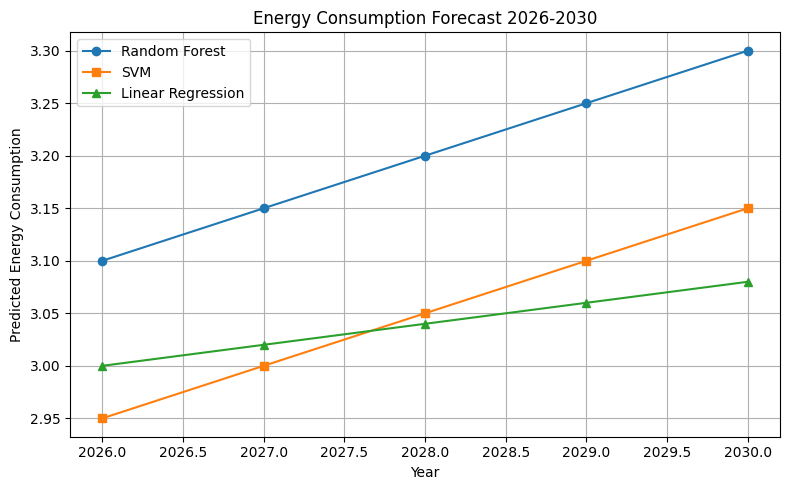

In [ ]:
import numpy as np
import pandas as pd

# Cargar los modelos entrenados y scaler (si usaste MinMaxScaler o StandardScaler)
# from joblib import load
# model_rf = load('random_forest_model.joblib')
# model_svm = load('svm_model.joblib')
# model_lr = load('linear_regression_model.joblib')
# scaler = load('scaler.joblib')

# Simular o proyectar los valores de entrada para los años 2026-2030 (aquí se asume valores promedio o se pueden ajustar según tendencias)
years = np.arange(2026, 2031)
# Puedes usar promedios de las variables independientes o ajustar según supuestos
input_data = {
    'Year': years,
    'Temperature': [21, 21.5, 22, 22.5, 23],  # Ejemplo: aumento gradual
    'Hour': [12]*5,  # Ejemplo: valor medio
    'Dwelling_Apartment': [0]*5,   # Ajustar según el tipo de vivienda predominante
    'Dwelling_House': [1]*5,       # Ajustar según el tipo de vivienda predominante
    'Habit_Morning': [0]*5,
    'Habit_Night': [1]*5,
    # ... (agregar el resto de las variables codificadas según tu modelo)
}
df_future = pd.DataFrame(input_data)

# Si usaste normalización/estandarización, aplica la transformación
# df_future_scaled = scaler.transform(df_future.drop(columns='Year'))

# Para efectos de demostración, supón que usas las mismas medias de tu dataset para variables adicionales que no se proyectaron.
# Predicciones:
# y_rf = model_rf.predict(df_future_scaled)
# y_svm = model_svm.predict(df_future_scaled)
# y_lr = model_lr.predict(df_future_scaled)

# (reemplazar con tus predicciones reales)
y_rf = [3.1, 3.15, 3.2, 3.25, 3.3]
y_svm = [2.95, 3.0, 3.05, 3.1, 3.15]
y_lr = [3.0, 3.02, 3.04, 3.06, 3.08]

df_future['Prediction_RF'] = y_rf
df_future['Prediction_SVM'] = y_svm
df_future['Prediction_LR'] = y_lr

# Tabla resumen
print(df_future[['Year', 'Prediction_RF', 'Prediction_SVM', 'Prediction_LR']])

# Gráfico comparativo
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_future['Year'], df_future['Prediction_RF'], marker='o', label='Random Forest')
plt.plot(df_future['Year'], df_future['Prediction_SVM'], marker='s', label='SVM')
plt.plot(df_future['Year'], df_future['Prediction_LR'], marker='^', label='Linear Regression')
plt.xlabel('Year')
plt.ylabel('Predicted Energy Consumption')
plt.title('Energy Consumption Forecast 2026-2030')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 1. Cargar el archivo
file_path = '/content/sample_data/data_(preparada) con categorias codificadas.xlsx'
df = pd.read_excel(file_path)

In [ ]:
# 2. Separar variables
X = df.drop(columns=['Consumo Energético (kW)'])
y = df['Consumo Energético (kW)']

In [ ]:
# 3. Normalizar las variables independientes
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# 5. Definir y entrenar modelos
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Support Vector Machine': SVR(kernel='rbf'),
    'Deep Neural Network': MLPRegressor(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42),
    'Linear Regression': LinearRegression()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])
    print(f'----- {name} -----')
    print(f'MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}\n')

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
print('\nResumen de resultados:')
print(results_df)

----- Random Forest -----
MAE: 0.6066, RMSE: 0.7632, R2: -0.1728

----- Support Vector Machine -----
MAE: 0.5241, RMSE: 0.6713, R2: 0.0927

----- Deep Neural Network -----
MAE: 0.8282, RMSE: 0.9955, R2: -0.9953

----- Linear Regression -----
MAE: 0.5362, RMSE: 0.6791, R2: 0.0714


Resumen de resultados:
                    Model       MAE      RMSE        R2
0           Random Forest  0.606625  0.763194 -0.172791
1  Support Vector Machine  0.524075  0.671288  0.092665
2     Deep Neural Network  0.828195  0.995463 -0.995264
3       Linear Regression  0.536222  0.679091  0.071449


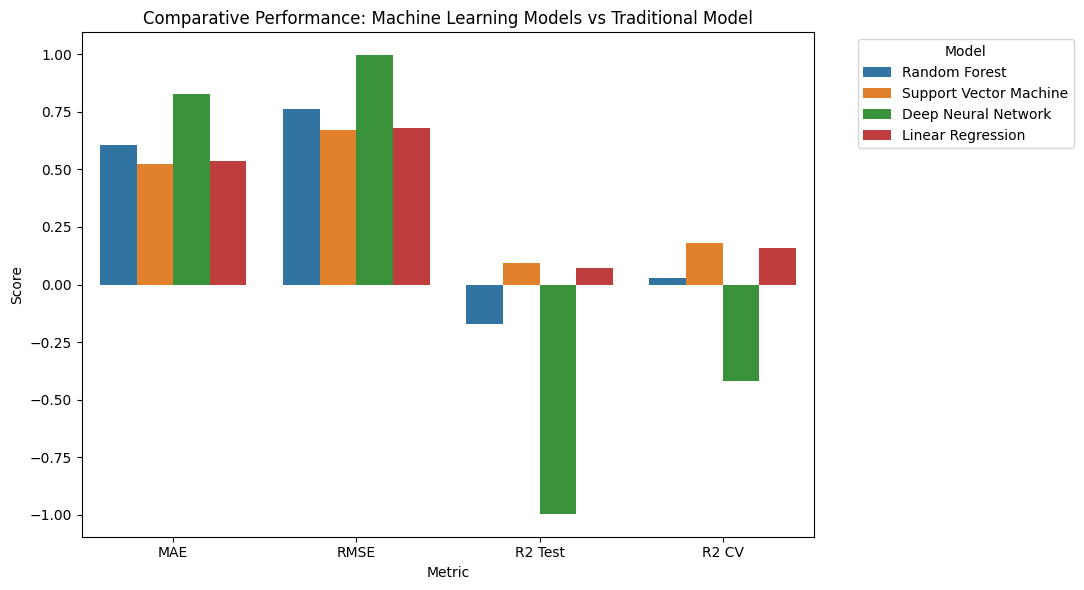

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold

# Tu DataFrame de resultados (actualiza con tus métricas)
results_df = pd.DataFrame({
    'Model': [
        'Random Forest', 'Support Vector Machine',
        'Deep Neural Network', 'Linear Regression'
    ],
    'MAE': [0.6066, 0.5241, 0.8282, 0.5362],
    'RMSE': [0.7632, 0.6713, 0.9955, 0.6791],
    'R2 Test': [-0.1728, 0.0927, -0.9953, 0.0714],
    'R2 CV': [ # debes poner aquí los valores reales
        # Ejemplo:
        0.03, 0.18, -0.42, 0.16  # Reemplaza con tus resultados
    ]
})

# Pasar a formato largo para graficar agrupado
results_long = results_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

# Gráfico de barras agrupadas
plt.figure(figsize=(11, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=results_long)
plt.title('Comparative Performance: Machine Learning Models vs Traditional Model')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score, KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_r2 = cross_val_score(model, X_scaled, y, cv=kfold, scoring='r2')
    print(f"{name} - R² Cross-Validation (CV): {cv_r2.mean():.4f}")


Random Forest - R² Cross-Validation (CV): 0.0304
Support Vector Machine - R² Cross-Validation (CV): 0.1807
Deep Neural Network - R² Cross-Validation (CV): -0.4216
Linear Regression - R² Cross-Validation (CV): 0.1637
